In [5]:
import os
import sys

repo_url = "https://github.com/chahineNejm/kernels_playground"
repo_name = repo_url.split("/")[-1]
%cd /content
if os.path.exists(repo_name):
    print(f"🗑️ Wiping old '{repo_name}' to clear out local changes...")
    !rm -rf {repo_name}

print(f"📥 Cloning fresh '{repo_name}'...")
!git clone {repo_url}

repo_path = os.path.abspath(repo_name)
if repo_path not in sys.path:
    sys.path.append(repo_path)
%cd {repo_name}

req_file = "first_tests/requirements.txt"
if os.path.exists(req_file):
    print("⚙️ Installing dependencies...")
    !pip install -q -r {req_file}

%load_ext autoreload
%autoreload 2
%cd first_tests

print("\n✅ Fresh setup complete! You are now inside the 'first_tests' folder.")
!git clone https://github.com/kernel-enthusiasts/Kernel-Mode-Decomposition-1D /content/KMD
import sys
sys.path.insert(0, "/content/KMD")
from datasets import get_dataset_config_names
import gc

/content
📥 Cloning fresh 'kernels_playground'...
Cloning into 'kernels_playground'...
remote: Enumerating objects: 317, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 317 (delta 9), reused 24 (delta 9), pack-reused 291 (from 1)
Receiving objects: 100% (317/317), 78.34 MiB | 24.52 MiB/s, done.
Resolving deltas: 100% (126/126), done.
/content/kernels_playground
⚙️ Installing dependencies...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.8/76.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.1/82.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 3.8 MB/s eta 0:00:00
/content/kernels_playground/first_tests

✅ Fresh setup complete! You are now inside the 'first_tests' folder.
Cloning into '/content/KMD'...
remote: Enumerating objects: 63, done.
remote: Counting objects: 100% (63/63), done.
remote: Compressing objects: 100% (62/62), done.
remote: Total 63 (delta 31), re

In [6]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import importlib


# local utils package
from utils.config import DEFAULT_CONFIG,DATASETS, PRETRAIN_BY_DOMAIN, EVAL_BY_FREQ,EVAL_BY_DOMAIN
from utils.data import (
    load_gift_dataset, quick_peek, dataset_summary, build_examples,
    normalize_by_history,prepare_examples
)
from utils.kernels import (fit_kernel_operator, predict_kernel_operator, rmse, relative_rmse,
RBFKernel, DTWKernel, LinearKernel, WaveletKernel)
from utils.viz import (
    plot_series, plot_series_grid, plot_distribution,
    plot_train_test_split, plot_kernel_heatmap,
    plot_residuals, plot_metric_summary,
    plot_predictions_for_domain,report_eval,compare_results,
)
from utils.decomposition import decompose_series
from utils.pipeline import train_eval, run_all_domains,scaling_study
from utils.preprocessing import slice_pretrain, slice_domain


In [7]:
import matplotlib
matplotlib.use("Agg")

# Patch KMD_lib.py for Colab compatibility
kmd_path = "/content/KMD/KMD_lib.py"
with open(kmd_path) as f:
    src = f.read()
src = src.replace("matplotlib.use('TkAgg')", "# matplotlib.use('TkAgg')")
src = src.replace('matplotlib.use("TkAgg")', '# matplotlib.use("TkAgg")')
src = src.replace("np.float,", "float,")
src = src.replace("np.float)", "float)")
src = src.replace("np.int,", "int,")
src = src.replace("np.int)", "int)")
src = src.replace("np.complex,", "complex,")
src = src.replace("np.complex)", "complex)")
with open(kmd_path, "w") as f:
    f.write(src)

import sys
sys.path.insert(0, "/content/KMD")
import KMD_lib

## Quick dataset exploration
Use these to poke around any config before running the full pipeline.

this is quite fun because we have meta data to play with and use better afterwards

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

bitbrains_fast_storage_5T_long/train.par(…):   0%|          | 0.00/41.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5000 [00:00<?, ? examples/s]

history: (7920,)  future: (720,)


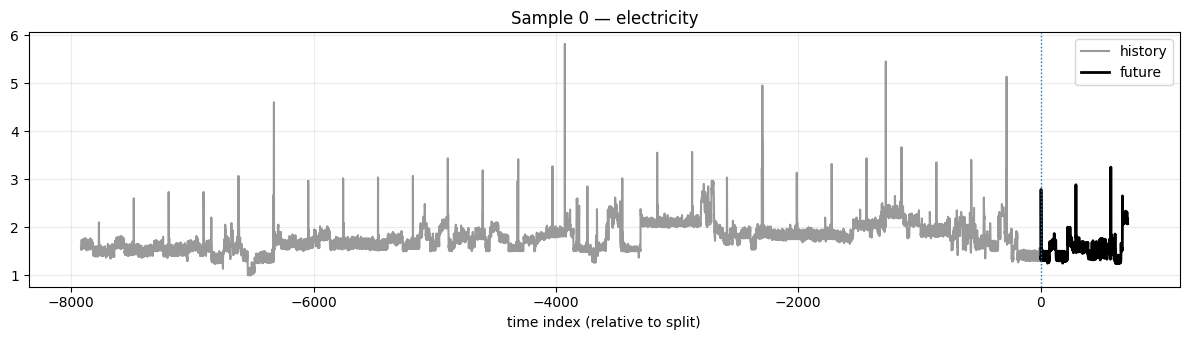

In [8]:
# Peek at one sample from parquet /eval
sample = quick_peek(index=1535, config="bitbrains_fast_storage_5T_long",dataset_name=DATASETS["eval"])
print(f"history: {sample['history'].shape}  future: {sample['future'].shape}")
plot_series(sample["history"], sample["future"], title="Sample 0 — electricity", history_context=10000,show=False)

In [9]:
# Grid view of several samples
examples_preview = build_examples(config="Traffic", start=0, stop =50 ,step = 2,dataset_name=DATASETS["eval"])
plot_series_grid(examples_preview)


loop_seattle_H_long/train.parquet:   0%|          | 0.00/22.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/646 [00:00<?, ? examples/s]

## Full kernel‑operator pipeline

In [10]:
dataset_to_fetch = "australian_electricity_demand"
raw = build_examples(dataset_to_fetch, start=0,dataset_name=DATASETS["pretrain"])
print(f"the dataset{dataset_to_fetch} is of size {len(raw)}")
lengths = [(len(e["history"]), len(e["future"])) for e in raw]
print(f"History range: {min(l[0] for l in lengths)} – {max(l[0] for l in lengths)}")
print(f"Future range:  {min(l[1] for l in lengths)} – {max(l[1] for l in lengths)}")

examples = prepare_examples(
    raw,
    history_len=int(3E4),
    future_len=700,
    min_history=1000,
    min_future=100,
)



README.md: 0.00B [00:00, ?B/s]

australian_electricity_demand/data-00000(…):   0%|          | 0.00/4.62M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

the datasetaustralian_electricity_demand is of size 5
History range: 230400 – 231936
Future range:  0 – 0


In [11]:
chunks = slice_domain(
    "Energy",
    future_len=700,
    min_history=1_000,
    max_history=10_000,
    min_future=200,
    max_future=1_000,
    max_series_per_subset=500,       # cap per subset
    skip_prefixes=("largest",),      # skip the huge ones
)

examples = prepare_examples(
    chunks,
    history_len=3000,
    future_len=700,
    min_history=1000,
    min_future=100,
)
gc.collect()

slicing series:   0%|          | 0/5 [00:00<?, ?it/s]

Skipping australian_electricity_demand due to error: slice_series() got an unexpected keyword argument 'series_id'


covid19_energy/data-00000-of-00001.arrow:   0%|          | 0.00/895k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

/content/kernels_playground/first_tests/utils/data.py:37: RuntimeWarning: overflow encountered in cast
  x = np.asarray(x, dtype=np.float16).ravel().copy()


...

residential_load_power/data-00001-of-000(…):   0%|          | 0.00/447M [00:00<?, ?B/s]

residential_load_power/data-00002-of-000(…):   0%|          | 0.00/454M [00:00<?, ?B/s]

residential_load_power/data-00003-of-000(…):   0%|          | 0.00/433M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

KeyboardInterrupt: 

In [ ]:
1/0

In [ ]:
#fucked up the ratio :)
my_train_indices = range(0, int(len(examples)*9/10))
resultRBF = train_eval(examples, kernel=RBFKernel(),train_indices=my_train_indices)

In [ ]:
plot_predictions_for_domain("Traffic", resultRBF.test_records, resultRBF.predictions,history_context=1000)

In [ ]:
resultL = train_eval(examples, kernel=LinearKernel(),train_indices=my_train_indices)

In [ ]:
plot_predictions_for_domain("Traffic", resultL.test_records, resultL.predictions,history_context=1000)

In [ ]:
# --- Mode 3: "coeffs" ---
# RBF on the full flattened CWT coefficient matrices.
# Richest representation but highest dimensional.
resultCWT = train_eval(examples, kernel=WaveletKernel(mode="coeffs", n_scales=64,scale_max =128, top_k=64),train_indices=my_train_indices)

In [ ]:
plot_predictions_for_domain("Traffic", resultCWT.test_records, resultCWT.predictions,history_context=1000)

In [ ]:
# auto-pick 8 log-spaced sizes
results_RBF = scaling_study(examples, kernel=RBFKernel(), domain="Traffic",test_indices = resultRBF.test_indices)

In [ ]:
import matplotlib.pyplot as plt
ns = [r.n_train for r in results_RBF]
plt.plot(ns, [r.mean_relative_rmse for r in results_RBF], marker='o', label='relRMSE')
plt.plot(ns, [r.mean_mase for r in results_RBF], marker='s', label='MASE')
plt.xlabel("n_train"); plt.legend(); plt.show()

In [ ]:
# or specify exactly which sizes
results_wavelets = scaling_study(examples, kernel=WaveletKernel(mode="coeffs", n_scales=64,scale_max =128, top_k=64),
                        domain = "Traffic",test_indices = resultRBF.test_indices)

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
ns = [r.n_train for r in results_wavelets]
plt.plot(ns, [r.mean_relative_rmse for r in results_wavelets], marker='o', label='relRMSE')
plt.plot(ns, [r.mean_mase for r in results_wavelets], marker='s', label='MASE')
plt.xlabel("n_train"); plt.legend(); plt.show()